# Insurance Claim Prediction — Machine Learning

**Objective:** Build and train three predictive models to classify insurance claims:
1. **Logistic Regression** — Interpretable baseline model
2. **Random Forest** — Ensemble of decision trees
3. **XGBoost** — Optimized gradient boosting

**Dataset:** 50,000 policyholders, target = `Claim` (0/1)

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
import os

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
%matplotlib inline

print('Libraries loaded successfully!')

Libraries loaded successfully!


## 2. Load and Inspect Data

In [2]:
df = pd.read_csv('../data/insurance_claim_dataset.csv')
print(f'Dataset shape: {df.shape}')
print(f'Claim rate: {df["Claim"].mean()*100:.2f}%')
print(f'Columns: {list(df.columns)}')

Dataset shape: (50000, 30)
Claim rate: 17.64%
Columns: ['Customer_ID', 'Age', 'Gender', 'Marital_Status', 'Occupation', 'Annual_Income', 'Credit_Score', 'Region', 'Vehicle_Type', 'Vehicle_Age', 'Vehicle_Value', 'Annual_Mileage', 'Engine_Size', 'Safety_Rating', 'Driving_Experience', 'Years_Licensed', 'Previous_Claims', 'Previous_Accidents', 'Traffic_Violations', 'Policy_Type', 'Coverage_Amount', 'Deductible', 'Annual_Premium', 'Policy_Duration', 'Urban_Rural', 'Parking_Type', 'Flood_Risk', 'Crime_Index', 'Claim', 'Claim_Amount']


## 3. Data Preparation

### 3.1 Separate Features and Target

In [3]:
target = 'Claim'
drop_cols = ['Customer_ID', 'Claim_Amount']

X = df.drop(columns=[target] + drop_cols)
y = df[target]

print(f'Features shape: {X.shape}')
print(f'Target shape: {y.shape}')
print(f'Feature columns ({len(X.columns)}):')
for col in X.columns:
    print(f'  - {col}')

Features shape: (50000, 27)
Target shape: (50000,)
Feature columns (27):
  - Age
  - Gender
  - Marital_Status
  - Occupation
  - Annual_Income
  - Credit_Score
  - Region
  - Vehicle_Type
  - Vehicle_Age
  - Vehicle_Value
  - Annual_Mileage
  - Engine_Size
  - Safety_Rating
  - Driving_Experience
  - Years_Licensed
  - Previous_Claims
  - Previous_Accidents
  - Traffic_Violations
  - Policy_Type
  - Coverage_Amount
  - Deductible
  - Annual_Premium
  - Policy_Duration
  - Urban_Rural
  - Parking_Type
  - Flood_Risk
  - Crime_Index


### 3.2 Identify Numeric and Categorical Columns

In [4]:
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f'Numeric columns ({len(numeric_cols)}):')
print(f'  {numeric_cols}')
print(f'\nCategorical columns ({len(categorical_cols)}):')
print(f'  {categorical_cols}')

Numeric columns (19):
  ['Age', 'Annual_Income', 'Credit_Score', 'Vehicle_Age', 'Vehicle_Value', 'Annual_Mileage', 'Engine_Size', 'Safety_Rating', 'Driving_Experience', 'Years_Licensed', 'Previous_Claims', 'Previous_Accidents', 'Traffic_Violations', 'Coverage_Amount', 'Deductible', 'Annual_Premium', 'Policy_Duration', 'Flood_Risk', 'Crime_Index']

Categorical columns (8):
  ['Gender', 'Marital_Status', 'Occupation', 'Region', 'Vehicle_Type', 'Policy_Type', 'Urban_Rural', 'Parking_Type']


### 3.3 Build Preprocessing Pipeline

We use `ColumnTransformer` to apply different preprocessing:
- **Numeric:** Median imputation + StandardScaler
- **Categorical:** Mode imputation + OneHotEncoder (drop first)

In [5]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='drop'
)

print('Preprocessing pipeline built!')
print('  - Numeric: Median Imputer + StandardScaler')
print('  - Categorical: Mode Imputer + OneHotEncoder')

Preprocessing pipeline built!
  - Numeric: Median Imputer + StandardScaler
  - Categorical: Mode Imputer + OneHotEncoder


### 3.4 Train-Test Split (Stratified 80-20)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Train size: {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)')
print(f'Test size:  {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)')
print(f'\nTrain claim rate: {y_train.mean()*100:.2f}%')
print(f'Test claim rate:  {y_test.mean()*100:.2f}%')

print('\nFitting preprocessor on training data...')
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

if hasattr(X_train_processed, 'toarray'):
    X_train_processed = X_train_processed.toarray()
    X_test_processed = X_test_processed.toarray()

print(f'\nProcessed train shape: {X_train_processed.shape}')
print(f'Processed test shape:  {X_test_processed.shape}')

os.makedirs('../models', exist_ok=True)
with open('../models/preprocessor.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)
print('\nPreprocessor saved to models/preprocessor.pkl')

Train size: 40,000 (80.0%)
Test size:  10,000 (20.0%)

Train claim rate: 17.64%
Test claim rate:  17.64%

Fitting preprocessor on training data...

Processed train shape: (40000, 40)
Processed test shape:  (10000, 40)

Preprocessor saved to models/preprocessor.pkl


## 4. Model 1: Logistic Regression

**Why Logistic Regression?** Industry standard in insurance, highly interpretable, well-calibrated probabilities.

In [7]:
print('=' * 60)
print('MODEL 1: LOGISTIC REGRESSION')
print('=' * 60)

lr_param_grid = {
    'C': [0.01, 0.1, 1.0, 10.0],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'saga'],
    'class_weight': [None, 'balanced']
}

lr_grid = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    param_grid=lr_param_grid,
    cv=5, scoring='roc_auc', n_jobs=-1, verbose=1
)

print('\nTraining Logistic Regression with hyperparameter tuning...')
lr_grid.fit(X_train_processed, y_train)

print(f'\nBest Parameters: {lr_grid.best_params_}')
print(f'Best CV ROC-AUC: {lr_grid.best_score_:.4f}')

lr_best = lr_grid.best_estimator_

y_pred_lr = lr_best.predict(X_test_processed)
y_prob_lr = lr_best.predict_proba(X_test_processed)[:, 1]

lr_auc = roc_auc_score(y_test, y_prob_lr)
lr_acc = accuracy_score(y_test, y_pred_lr)
print(f'\nTest ROC-AUC: {lr_auc:.4f}')
print(f'Test Accuracy: {lr_acc:.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred_lr))

MODEL 1: LOGISTIC REGRESSION

Training Logistic Regression with hyperparameter tuning...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best Parameters: {'C': 1.0, 'class_weight': None, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV ROC-AUC: 0.6806

Test ROC-AUC: 0.6940
Test Accuracy: 0.8281

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.99      0.90      8236
           1       0.63      0.06      0.11      1764

    accuracy                           0.83     10000
   macro avg       0.73      0.53      0.51     10000
weighted avg       0.80      0.83      0.76     10000



### Logistic Regression Coefficients

One of the biggest advantages of Logistic Regression is interpretability.

In [8]:
numeric_features = numeric_cols
cat_features = []
for i, (name, transformer, cols) in enumerate(preprocessor.transformers_):
    if name == 'cat':
        ohe = transformer.named_steps['onehot']
        cat_features = ohe.get_feature_names_out(cols).tolist()

all_features = numeric_features + cat_features

coefficients = lr_best.coef_[0]
intercept = lr_best.intercept_[0]

coef_df = pd.DataFrame({
    'Feature': all_features,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
}).sort_values('Abs_Coefficient', ascending=False)

print(f'Intercept: {intercept:.4f}')
print(f'\nTop 20 Most Important Features (by absolute coefficient):')
print('=' * 70)
print(f'{"Feature":35s} {"Coefficient":>12s}')
print('=' * 70)
for _, row in coef_df.head(20).iterrows():
    direction = 'Higher Risk' if row['Coefficient'] > 0 else 'Lower Risk'
    print(f"{row['Feature']:35s} {row['Coefficient']:>+12.4f}  {direction}")

coef_df.to_csv('../models/lr_coefficients.csv', index=False)
print('\nCoefficients saved to models/lr_coefficients.csv')

Intercept: -1.3709

Top 20 Most Important Features (by absolute coefficient):
Feature                              Coefficient
Policy_Type_Premium                      -1.5910  Lower Risk
Annual_Premium                           +0.6871  Higher Risk
Policy_Type_Standard                     -0.6574  Lower Risk
Parking_Type_Street                      +0.2773  Higher Risk
Region_South                             +0.2520  Higher Risk
Traffic_Violations                       +0.2078  Higher Risk
Urban_Rural_Urban                        +0.1912  Higher Risk
Previous_Claims                          +0.1877  Higher Risk
Vehicle_Type_SUV                         -0.1720  Lower Risk
Vehicle_Type_Truck                       -0.1658  Lower Risk
Vehicle_Type_Minivan                     +0.1307  Higher Risk
Previous_Accidents                       +0.1302  Higher Risk
Vehicle_Type_Sports Car                  -0.1141  Lower Risk
Occupation_Unemployed                    +0.1097  Higher Risk
Gender_Mal

## 5. Model 2: Random Forest

**Why Random Forest?** Captures non-linear relationships, feature interactions, robust to outliers.

In [9]:
print('=' * 60)
print('MODEL 2: RANDOM FOREST')
print('=' * 60)

rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [10, 20, 50],
    'min_samples_leaf': [5, 10, 20],
    'max_features': ['sqrt', 'log2'],
    'class_weight': [None, 'balanced', 'balanced_subsample']
}

rf_random = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1, verbose=0),
    param_distributions=rf_param_grid,
    n_iter=30, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1,
    random_state=42
)

print('\nTraining Random Forest with hyperparameter tuning...')
rf_random.fit(X_train_processed, y_train)

print(f'\nBest Parameters: {rf_random.best_params_}')
print(f'Best CV ROC-AUC: {rf_random.best_score_:.4f}')

rf_best = rf_random.best_estimator_

y_pred_rf = rf_best.predict(X_test_processed)
y_prob_rf = rf_best.predict_proba(X_test_processed)[:, 1]

rf_auc = roc_auc_score(y_test, y_prob_rf)
rf_acc = accuracy_score(y_test, y_pred_rf)
print(f'\nTest ROC-AUC: {rf_auc:.4f}')
print(f'Test Accuracy: {rf_acc:.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred_rf))

MODEL 2: RANDOM FOREST

Training Random Forest with hyperparameter tuning...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best Parameters: {'n_estimators': 200, 'min_samples_split': 20, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_depth': 10, 'class_weight': None}
Best CV ROC-AUC: 0.6767

Test ROC-AUC: 0.6896
Test Accuracy: 0.8259

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.99      0.90      8236
           1       0.57      0.05      0.10      1764

    accuracy                           0.83     10000
   macro avg       0.70      0.52      0.50     10000
weighted avg       0.78      0.83      0.76     10000



### Random Forest Feature Importance

Top 20 Most Important Features (Random Forest):
Years_Licensed                      0.1308  |||||||||||||
Age                                 0.1135  |||||||||||
Driving_Experience                  0.0958  |||||||||
Credit_Score                        0.0782  |||||||
Annual_Premium                      0.0617  ||||||
Vehicle_Value                       0.0459  ||||
Annual_Mileage                      0.0446  ||||
Traffic_Violations                  0.0426  ||||
Annual_Income                       0.0424  ||||
Coverage_Amount                     0.0422  ||||
Engine_Size                         0.0364  |||
Crime_Index                         0.0352  |||
Previous_Claims                     0.0317  |||
Previous_Accidents                  0.0263  ||
Vehicle_Age                         0.0211  ||
Parking_Type_Street                 0.0206  ||
Vehicle_Type_Sports Car             0.0169  |
Safety_Rating                       0.0128  |
Region_South                        0.0114  |
Flood_Risk   

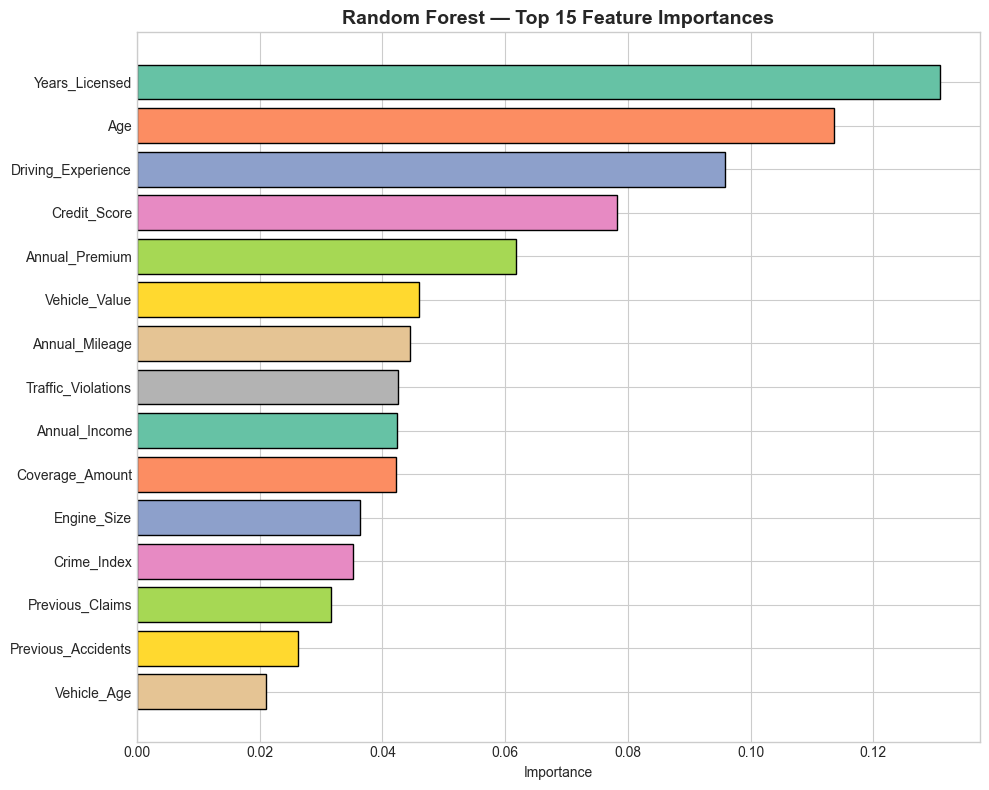


Feature importance saved.


In [10]:
rf_importance = rf_best.feature_importances_
rf_imp_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': rf_importance
}).sort_values('Importance', ascending=False)

print('Top 20 Most Important Features (Random Forest):')
print('=' * 60)
for _, row in rf_imp_df.head(20).iterrows():
    bar = '|' * int(row['Importance'] * 100)
    print(f"{row['Feature']:35s} {row['Importance']:.4f}  {bar}")

fig, ax = plt.subplots(figsize=(10, 8))
top_features = rf_imp_df.head(15)
ax.barh(range(len(top_features)), top_features['Importance'].values,
        color=sns.color_palette('Set2'), edgecolor='black')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['Feature'].values)
ax.invert_yaxis()
ax.set_xlabel('Importance')
ax.set_title('Random Forest — Top 15 Feature Importances', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

rf_imp_df.to_csv('../models/rf_feature_importance.csv', index=False)
print('\nFeature importance saved.')

## 6. Model 3: XGBoost

**Why XGBoost?** State-of-the-art gradient boosting, built-in regularization, handles missing values.

In [11]:
print('=' * 60)
print('MODEL 3: XGBOOST')
print('=' * 60)

xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7, 9],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 1.0],
    'reg_lambda': [1.0, 2.0, 3.0],
    'scale_pos_weight': [1, 4, 7]
}

xgb_random = RandomizedSearchCV(
    xgb.XGBClassifier(random_state=42, verbosity=0,
                      use_label_encoder=False, eval_metric='logloss'),
    param_distributions=xgb_param_grid,
    n_iter=30, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1,
    random_state=42
)

print('\nTraining XGBoost with hyperparameter tuning...')
xgb_random.fit(X_train_processed, y_train)

print(f'\nBest Parameters: {xgb_random.best_params_}')
print(f'Best CV ROC-AUC: {xgb_random.best_score_:.4f}')

xgb_best = xgb_random.best_estimator_

y_pred_xgb = xgb_best.predict(X_test_processed)
y_prob_xgb = xgb_best.predict_proba(X_test_processed)[:, 1]

xgb_auc = roc_auc_score(y_test, y_prob_xgb)
xgb_acc = accuracy_score(y_test, y_pred_xgb)
print(f'\nTest ROC-AUC: {xgb_auc:.4f}')
print(f'Test Accuracy: {xgb_acc:.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred_xgb))

MODEL 3: XGBOOST

Training XGBoost with hyperparameter tuning...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best Parameters: {'subsample': 0.8, 'scale_pos_weight': 1, 'reg_lambda': 2.0, 'reg_alpha': 1.0, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
Best CV ROC-AUC: 0.6841

Test ROC-AUC: 0.6957
Test Accuracy: 0.8273

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.99      0.90      8236
           1       0.58      0.08      0.14      1764

    accuracy                           0.83     10000
   macro avg       0.70      0.53      0.52     10000
weighted avg       0.79      0.83      0.77     10000



### XGBoost Feature Importance

Top 20 Most Important Features (XGBoost):
Age                                 0.2069  ||||||||||||||||||||
Driving_Experience                  0.1214  ||||||||||||
Vehicle_Type_Sports Car             0.0563  |||||
Traffic_Violations                  0.0467  ||||
Parking_Type_Street                 0.0466  ||||
Previous_Claims                     0.0369  |||
Region_South                        0.0351  |||
Previous_Accidents                  0.0344  |||
Years_Licensed                      0.0317  |||
Credit_Score                        0.0297  ||
Urban_Rural_Urban                   0.0275  ||
Flood_Risk                          0.0254  ||
Annual_Premium                      0.0211  ||
Engine_Size                         0.0184  |
Marital_Status_Widowed              0.0175  |
Annual_Mileage                      0.0155  |
Vehicle_Type_Truck                  0.0149  |
Gender_Male                         0.0145  |
Policy_Type_Premium                 0.0143  |
Coverage_Amount                 

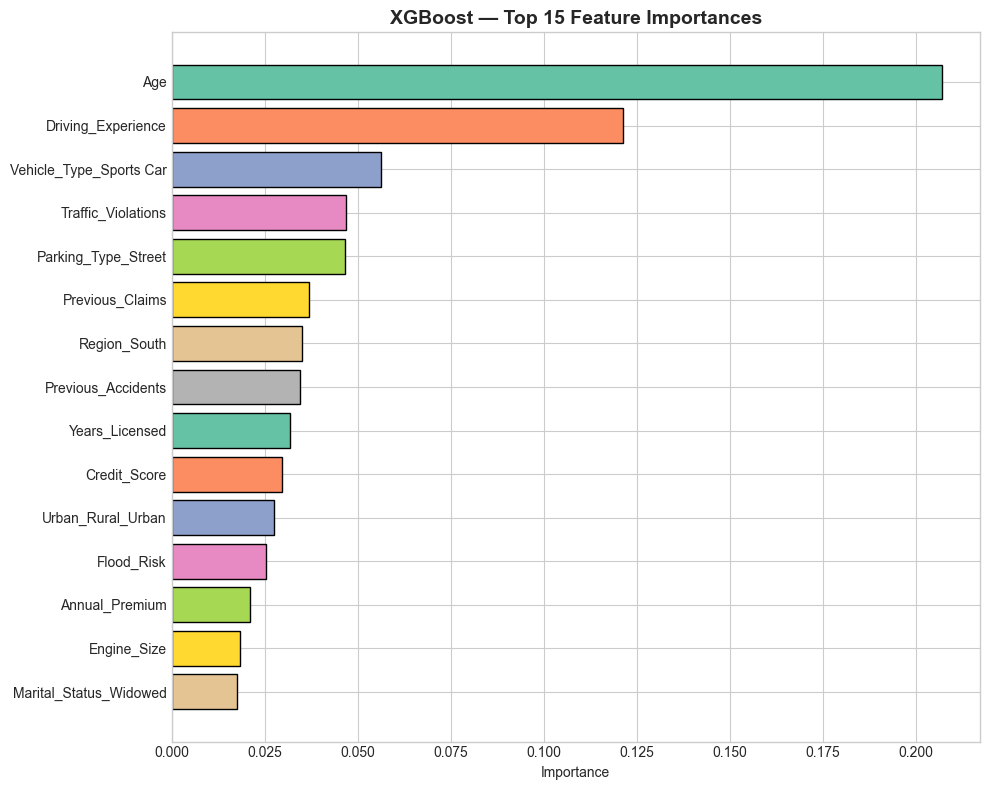


Feature importance saved.


In [12]:
xgb_importance = xgb_best.feature_importances_
xgb_imp_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': xgb_importance
}).sort_values('Importance', ascending=False)

print('Top 20 Most Important Features (XGBoost):')
print('=' * 60)
for _, row in xgb_imp_df.head(20).iterrows():
    bar = '|' * int(row['Importance'] * 100)
    print(f"{row['Feature']:35s} {row['Importance']:.4f}  {bar}")

fig, ax = plt.subplots(figsize=(10, 8))
top_features = xgb_imp_df.head(15)
ax.barh(range(len(top_features)), top_features['Importance'].values,
        color=sns.color_palette('Set2'), edgecolor='black')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['Feature'].values)
ax.invert_yaxis()
ax.set_xlabel('Importance')
ax.set_title('XGBoost — Top 15 Feature Importances', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/xgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

xgb_imp_df.to_csv('../models/xgb_feature_importance.csv', index=False)
print('\nFeature importance saved.')

## 7. Save Models and Predictions

In [13]:
os.makedirs('../models', exist_ok=True)

models = {
    'logistic_regression': lr_best,
    'random_forest': rf_best,
    'xgboost': xgb_best
}

for name, model in models.items():
    path = f'../models/{name}.pkl'
    with open(path, 'wb') as f:
        pickle.dump(model, f)
    print(f'Saved: {path}')

predictions_df = pd.DataFrame({
    'y_test': y_test,
    'y_prob_lr': y_prob_lr, 'y_pred_lr': y_pred_lr,
    'y_prob_rf': y_prob_rf, 'y_pred_rf': y_pred_rf,
    'y_prob_xgb': y_prob_xgb, 'y_pred_xgb': y_pred_xgb,
})
predictions_df.to_csv('../models/test_predictions.csv', index=False)
print('Test predictions saved to models/test_predictions.csv')

Saved: ../models/logistic_regression.pkl
Saved: ../models/random_forest.pkl
Saved: ../models/xgboost.pkl
Test predictions saved to models/test_predictions.csv


## 8. Quick Summary

In [14]:
print('=' * 60)
print('MODEL COMPARISON (TEST SET)')
print('=' * 60)
print(f'{"Model":25s} {"Accuracy":>10s} {"ROC-AUC":>10s}')
print('-' * 60)
print(f'{"Logistic Regression":25s} {lr_acc:>10.4f} {lr_auc:>10.4f}')
print(f'{"Random Forest":25s} {rf_acc:>10.4f} {rf_auc:>10.4f}')
print(f'{"XGBoost":25s} {xgb_acc:>10.4f} {xgb_auc:>10.4f}')
print('-' * 60)

print('\nNEXT STEP: Open 03_Model_Evaluation.ipynb for detailed comparison')

MODEL COMPARISON (TEST SET)
Model                       Accuracy    ROC-AUC
------------------------------------------------------------
Logistic Regression           0.8281     0.6940
Random Forest                 0.8259     0.6896
XGBoost                       0.8273     0.6957
------------------------------------------------------------

NEXT STEP: Open 03_Model_Evaluation.ipynb for detailed comparison
